In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report


In [2]:
# 1. Đọc dữ liệu
df = pd.read_csv("german_credit_data.csv")


xóa trungf lặp dữ liệu

In [4]:
df = df.drop_duplicates()
print("Sau khi xóa trùng:", df.shape)

Sau khi xóa trùng: (1000, 10)


In [7]:
# Tách biến số và biến phân loại
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [8]:
from sklearn.impute import SimpleImputer

# Xử lý biến số
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Xử lý biến phân loại (chỉ khi có biến phân loại)
cat_imputer = SimpleImputer(strategy='most_frequent')
if not cat_cols.empty:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# One_Hot Encoding

In [ ]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder.fit_transform(df[cat_cols])

# Tạo DataFrame mới từ dữ liệu đã encode
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_cols))

# Ghép lại với dữ liệu gốc
df = df.drop(columns=cat_cols)
df = pd.concat([df, encoded_df], axis=1)

In [10]:
# 2. Tiền xử lý dữ liệu
# kiểm tra cột bị thiếu
df = df.rename(columns={'Unnamed: 0': 'NO'})
df['NO'] = df['NO'] + 1

kiểm tra dữ liệu

In [11]:
print("Dữ liệu sau xử lý:", df.shape)
print(df.head())
print(df.isnull().sum())  # kiểm tra còn thiếu không

Dữ liệu sau xử lý: (1000, 10)
    NO   Age     Sex  Job Housing Saving accounts Checking account  \
0  1.0  67.0    male  2.0     own          little           little   
1  2.0  22.0  female  2.0     own          little         moderate   
2  3.0  49.0    male  1.0     own          little           little   
3  4.0  45.0    male  2.0    free          little           little   
4  5.0  53.0    male  2.0    free          little           little   

   Credit amount  Duration              Purpose  
0         1169.0       6.0             radio/TV  
1         5951.0      48.0             radio/TV  
2         2096.0      12.0            education  
3         7882.0      42.0  furniture/equipment  
4         4870.0      24.0                  car  
NO                  0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


# Lưu dữ liệu đã làm sạch

In [12]:
df.to_csv("german_credit_data_cleaned.csv", index=False)

In [13]:
# Loại bỏ dòng thiếu dữ liệu
df = df.dropna()

In [14]:
# Xác định biến định tính
categorical_cols = ['laufkont','sparkont','famges','buerge','verm','beruf','wohn']

# Thống kê mô tả

In [15]:
print("\nThống kê mô tả cơ bản:\n", df.describe())

print("\nTuổi - mean:", df['Age'].mean(), 
      "median:", df['Age'].median(), 
      "std:", df['Age'].std())

print("Khoản vay - mean:", df['Credit amount'].mean(), 
      "median:", df['Credit amount'].median(), 
      "std:", df['Credit amount'].std())



Thống kê mô tả cơ bản:
                 NO          Age          Job  Credit amount     Duration
count  1000.000000  1000.000000  1000.000000    1000.000000  1000.000000
mean    500.500000    35.546000     1.904000    3271.258000    20.903000
std     288.819436    11.375469     0.653614    2822.736876    12.058814
min       1.000000    19.000000     0.000000     250.000000     4.000000
25%     250.750000    27.000000     2.000000    1365.500000    12.000000
50%     500.500000    33.000000     2.000000    2319.500000    18.000000
75%     750.250000    42.000000     2.000000    3972.250000    24.000000
max    1000.000000    75.000000     3.000000   18424.000000    72.000000

Tuổi - mean: 35.546 median: 33.0 std: 11.375468574317502
Khoản vay - mean: 3271.258 median: 2319.5 std: 2822.73687596044


# 1. Thống kê cơ bản (df.describe())
Bảng hiển thị các chỉ số cho 5 biến: NO, Age, Job, Credit amount, Duration.
- count: số lượng quan sát (1000 dòng dữ liệu).
- mean: giá trị trung bình.
- std: độ lệch chuẩn (mức độ phân tán quanh trung bình).
- min, max: giá trị nhỏ nhất và lớn nhất.
- 25%, 50%, 75%: các mốc phân vị (quartiles), giúp hiểu phân bố dữ liệu.
Ví dụ:
- Tuổi (Age) có mean = 35.5, min = 18, max = 75 → dữ liệu trải dài từ thanh niên đến người lớn tuổi.
- Khoản vay (Credit amount) có mean ≈ 3271, nhưng max = 18424 → cho thấy có một số khoản vay rất lớn, làm trung bình bị kéo lên.
- Duration (thời hạn vay) trung bình khoảng 21 tháng, dao động từ 4 đến 72 tháng.

# 2. Phân tích chi tiết từng biến
- Tuổi (Age)
- Trung bình: 35.5 tuổi.
- Trung vị: 33 tuổi (nhỏ hơn trung bình → phân bố lệch phải, có một số người lớn tuổi kéo trung bình lên).
- Độ lệch chuẩn: 11.4 → mức phân tán vừa phải.
- Khoản vay (Credit amount)
- Trung bình: 3271.
- Trung vị: 2319.5 (thấp hơn trung bình khá nhiều → dữ liệu lệch phải, có những khoản vay cực lớn).
- Độ lệch chuẩn: 2822.7 → rất cao, chứng tỏ dữ liệu phân tán mạnh.
- Thời hạn vay (Duration)
- Trung bình: 20.9 tháng.
- Trung vị: 18 tháng.
- Độ lệch chuẩn: 12.1 → có sự đa dạng về thời hạn vay, từ ngắn (4 tháng) đến dài (72 tháng).

# 3. Ý nghĩa tổng quát
- Bộ dữ liệu có 1000 khách hàng.
- Tuổi chủ yếu tập trung quanh 30–40 tuổi.
- Khoản vay có sự chênh lệch lớn: phần lớn vay vài nghìn, nhưng có một số trường hợp vay tới hàng chục nghìn.
- Thời hạn vay thường rơi vào khoảng 1–2 năm, nhưng cũng có hợp đồng dài hạn đến 6 năm.


In [27]:
# Đọc file ĐÃ LÀM SẠCH
df_cleaned = pd.read_csv("german_credit_data_cleaned.csv")

# Khai báo 3 biến định lượng cần tính toán
cac_bien_so = ['Age', 'Credit amount', 'Duration']

# Tính toán các đại lượng: mean, median, min, max, std
bang_thong_ke = df_cleaned[cac_bien_so].agg(['mean', 'median', 'min', 'max', 'std'])

# Làm tròn 2 chữ số thập phân và đổi tên hàng cho đẹp
bang_thong_ke = bang_thong_ke.round(2)
bang_thong_ke.index = ['Trung bình (Mean)', 'Trung vị (Median)', 'Nhỏ nhất (Min)', 'Lớn nhất (Max)', 'Độ lệch chuẩn (Std)']

# Hiển thị bảng kết quả ra màn hình
print("BẢNG THỐNG KÊ MÔ TẢ TỪ DỮ LIỆU ĐÃ LÀM SẠCH:")
display(bang_thong_ke)

BẢNG THỐNG KÊ MÔ TẢ TỪ DỮ LIỆU ĐÃ LÀM SẠCH:


,Age,Credit amount,Duration
Trung bình (Mean),35.55,3271.26,20.90
Trung vị (Median),33.00,2319.50,18.00
Nhỏ nhất (Min),19.00,250.00,4.00
Lớn nhất (Max),75.00,18424.00,72.00
Độ lệch chuẩn (Std),11.38,2822.74,12.06


# 3. Phân tích ý nghĩa
- Tuổi (Age)
- Trung bình: 35.6 tuổi.
- Trung vị: 33 tuổi → nhỏ hơn trung bình, cho thấy phân bố lệch phải (có một số người lớn tuổi kéo trung bình lên).
- Độ lệch chuẩn: 11.4 → mức phân tán vừa phải, đa số khách hàng trong khoảng 25–45 tuổi.
- Khoản vay (Credit amount)
- Trung bình: 3271.
- Trung vị: 2319.5 → thấp hơn trung bình khá nhiều, chứng tỏ dữ liệu lệch phải mạnh (có những khoản vay cực lớn).
- Độ lệch chuẩn: 2822.7 → rất cao, phản ánh sự chênh lệch lớn giữa các khoản vay.
- Min = 250, Max = 18424 → khoảng dao động rất rộng

- Thời hạn vay (Duration)
- Trung bình: 20.9 tháng.
- Trung vị: 18 tháng → thấp hơn trung bình, cũng có xu hướng lệch phải.
- Độ lệch chuẩn: 12.1 → mức phân tán khá lớn.
- Min = 4 tháng, Max = 72 tháng → có cả khoản vay ngắn hạn và dài hạn (tới 6 năm).

# 4. Tổng kết
- Tuổi: tập trung quanh 30–40 tuổi, nhưng có một số khách hàng lớn tuổi hơn.
- Khoản vay: phân bố rất lệch, phần lớn vay vài nghìn nhưng có một số khoản vay cực lớn kéo trung bình lên.
- Thời hạn vay: đa số khoảng 1–2 năm, nhưng có hợp đồng dài hạn đến 6 năm.
👉 Nhìn chung, cả Age, Credit amount, Duration đều có phân bố lệch phải. Trong trường hợp này, trung vị phản ánh sát thực tế hơn trung bình, vì trung bình bị ảnh hưởng bởi các giá trị cực lớn.


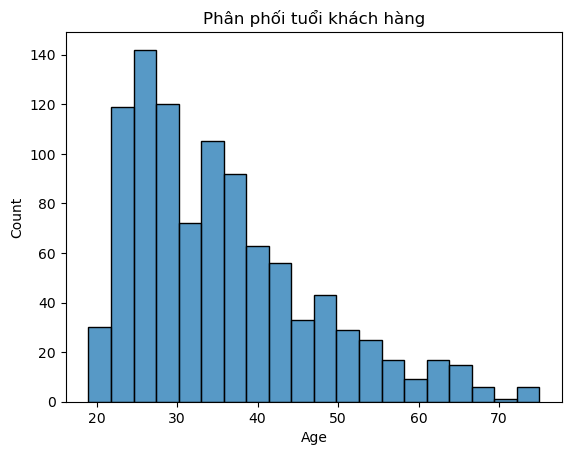

In [18]:
# Histogram
sns.histplot(data=df, x="Age", bins=20)
plt.title("Phân phối tuổi khách hàng")
plt.show()


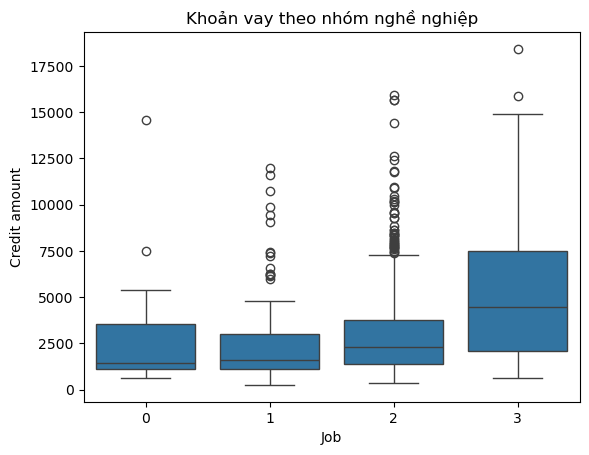

In [19]:
# boxplot
sns.boxplot(x="Job", y="Credit amount", data=df)
plt.title("Khoản vay theo nhóm nghề nghiệp")
plt.show()



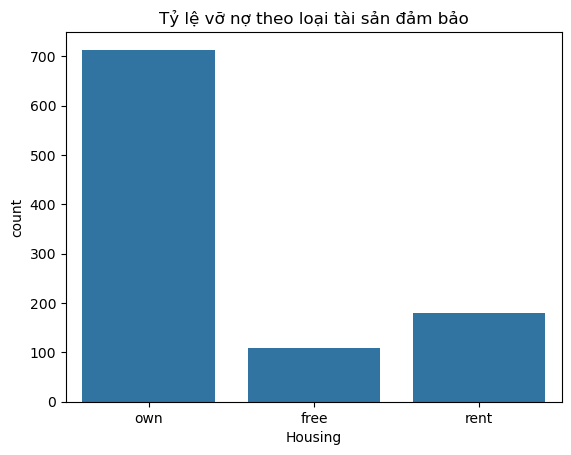

In [20]:
sns.countplot(x="Housing", data=df)
plt.title("Tỷ lệ vỡ nợ theo loại tài sản đảm bảo")
plt.show()


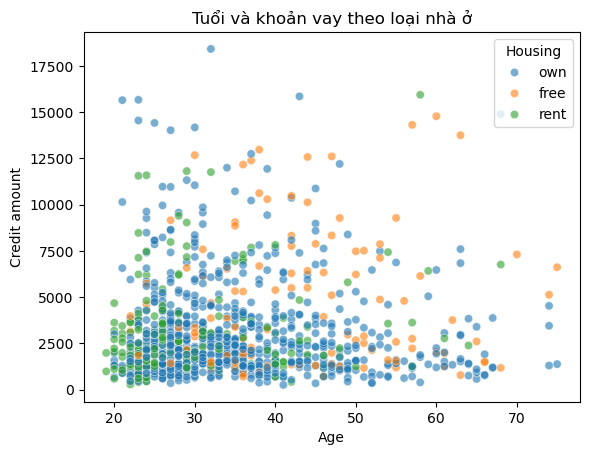

In [21]:
sns.scatterplot(x="Age", y="Credit amount", hue="Housing", data=df, alpha=0.6)
plt.title("Tuổi và khoản vay theo loại nhà ở")
plt.show()

# Heatmap

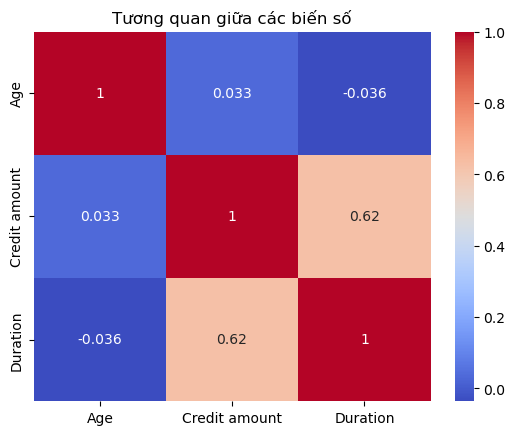

In [22]:
# Heatmap tương quan
corr = df[['Age','Credit amount','Duration']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Tương quan giữa các biến số")
plt.show()

# 1. Ý nghĩa của heatmap
Heatmap hiển thị hệ số tương quan (correlation coefficient) giữa các biến định lượng: Age, Credit amount, Duration.
- Giá trị nằm trong khoảng từ -1 đến 1.
- Gần 1 → tương quan thuận mạnh (cùng tăng/giảm).
- Gần -1 → tương quan nghịch mạnh (một tăng, một giảm).
- Gần 0 → hầu như không có mối liên hệ.

# 2. Kết quả cụ thể
- Age – Credit amount: 0.033
→ Rất gần 0, nghĩa là tuổi gần như không ảnh hưởng đến số tiền vay.
- Age – Duration: -0.036
→ Gần 0, nhưng hơi âm → tuổi không liên quan đáng kể đến thời hạn vay, có thể người trẻ và người lớn tuổi đều vay với thời hạn đa dạng.
- Credit amount – Duration: 0.62
→ Tương quan thuận khá mạnh. Khoản vay càng lớn thì thời hạn vay càng dài. Đây là mối quan hệ hợp lý: vay nhiều tiền thường cần thời gian dài hơn để trả.
# 3. Ý nghĩa thực tiễn
- Tuổi không phải yếu tố quyết định trong việc vay bao nhiêu hoặc vay bao lâu.
- Khoản vay và thời hạn vay có mối quan hệ chặt chẽ → ngân hàng có thể dựa vào đó để thiết kế sản phẩm tín dụng: khoản vay lớn thường đi kèm thời hạn dài.
- Heatmap giúp nhanh chóng nhận diện mối quan hệ giữa các biến, thay vì chỉ nhìn vào bảng số liệu.


In [24]:
# 5. Chuẩn bị dữ liệu cho mô hình
X = df.drop(["Purpose"], axis=1)  # giả sử Purpose là biến định tính không dùng trực tiếp
y = (df['Credit amount'] > df['Credit amount'].median()).astype(int)  
# Tạm thời định nghĩa nhãn: khoản vay lớn hơn median = rủi ro cao

categorical_cols = ['Sex','Job','Housing','Saving accounts','Checking account']
ct = ColumnTransformer([("encoder", OneHotEncoder(), categorical_cols)], remainder='passthrough')
X_encoded = ct.fit_transform(X)

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)



In [25]:
# 6. Huấn luyện Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Dự đoán
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

c:\Users\anhng\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
# 7. Đánh giá mô hình
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[103   3]
 [  0  94]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99       106
           1       0.97      1.00      0.98        94

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200

AUC-ROC: 0.9996989160979526
